## Imports & config

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd()
if not (ROOT / "final_data").exists() and (ROOT.parent / "final_data").exists():
    ROOT = ROOT.parent

FINAL_DATA_DIR = ROOT / "final_data"
SPLIT_FOLDERS = {
    "train": "train",
    "val": "validate",
    "test": "test",
}
SPLIT_CSVS = {
    "train": ROOT / "train.csv",
    "val": ROOT / "val.csv",
    "test": ROOT / "test.csv",
}

LABELS = [
    "No gesture",
    "Swiping Down",
    "Swiping Left",
    "Swiping Right",
    "Swiping Up",
    "Turning Hand Clockwise",
    "Turning Hand Counterclockwise",
    "Zooming In With Two Fingers",
    "Zooming Out With Two Fingers",
]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

NUM_FRAMES = 37
INPUT_SIZE = 63
NUM_CLASSES = len(LABELS)
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Dataset

In [ ]:
class GestureDataset(Dataset):
    def __init__(self, split):
        folder = SPLIT_FOLDERS[split]
        data_dir = FINAL_DATA_DIR / folder
        metadata = pd.read_csv(SPLIT_CSVS[split])

        self.samples = []
        for _, row in metadata.iterrows():
            video_id = int(row["video_id"])
            npy_path = data_dir / f"{video_id}.npy"
            if not npy_path.exists():
                continue
            self.samples.append(
                (npy_path, LABEL_TO_IDX[row["label"]])
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, label = self.samples[idx]
        seq = np.load(npy_path).astype(np.float32)
        return torch.from_numpy(seq), torch.tensor(label, dtype=torch.long)


train_dataset = GestureDataset("train")
val_dataset = GestureDataset("val")
test_dataset = GestureDataset("test")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 11797
Val:   1492
Test:  1470


## Bi-LSTM model

In [ ]:
class GestureBiLSTM(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        _, (hidden, _) = self.lstm(x)
        # hidden: (num_layers * 2, batch, hidden_size)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        last_hidden = torch.cat([forward_hidden, backward_hidden], dim=1)
        logits = self.classifier(self.dropout(last_hidden))
        return logits


model = GestureBiLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

Trainable parameters: 594,181
GestureBiLSTM(
  (lstm): LSTM(63, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=5, bias=True)
)


## Training (early stopping on validation loss)

In [ ]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for sequences, labels in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(sequences)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
model.to(device)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 01 | train loss 0.8743 acc 0.6888 | val loss 0.5100 acc 0.8418
Epoch 02 | train loss 0.4486 acc 0.8517 | val loss 0.4868 acc 0.8505
Epoch 03 | train loss 0.3643 acc 0.8863 | val loss 0.4828 acc 0.8552
Epoch 04 | train loss 0.3606 acc 0.8884 | val loss 0.3714 acc 0.8827
Epoch 05 | train loss 0.2999 acc 0.9067 | val loss 0.3406 acc 0.8901
Epoch 06 | train loss 0.2818 acc 0.9097 | val loss 0.3141 acc 0.9008
Epoch 07 | train loss 0.2583 acc 0.9175 | val loss 0.2922 acc 0.9129
Epoch 08 | train loss 0.2540 acc 0.9203 | val loss 0.2809 acc 0.9142
Epoch 09 | train loss 0.2364 acc 0.9240 | val loss 0.2864 acc 0.9115
Epoch 10 | train loss 0.2265 acc 0.9272 | val loss 0.2469 acc 0.9243
Epoch 11 | train loss 0.2177 acc 0.9306 | val loss 0.2841 acc 0.9129
Epoch 12 | train loss 0.2128 acc 0.9326 | val loss 0.2859 acc 0.9075
Epoch 13 | train loss 0.1986 acc 0.9378 | val loss 0.2495 acc 0.9249
Epoch 14 | train loss 0.1987 acc 0.9368 | val loss 0.3061 acc 0.9075
Epoch 15 | train loss 0.1941 acc 0

## Training curves

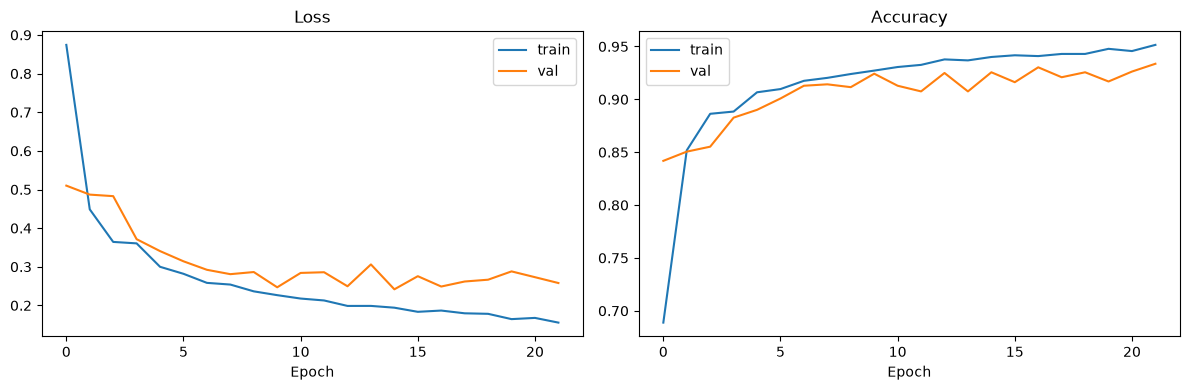

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Test evaluation

Test loss: 0.2280
Test accuracy: 0.9231

Classification report:
               precision    recall  f1-score   support

   No gesture     0.9347    0.9555    0.9450       719
 Swiping Down     0.8976    0.9246    0.9109       199
 Swiping Left     0.9506    0.8415    0.8928       183
Swiping Right     0.9045    0.9096    0.9070       177
   Swiping Up     0.9000    0.8906    0.8953       192

     accuracy                         0.9231      1470
    macro avg     0.9175    0.9044    0.9102      1470
 weighted avg     0.9235    0.9231    0.9228      1470



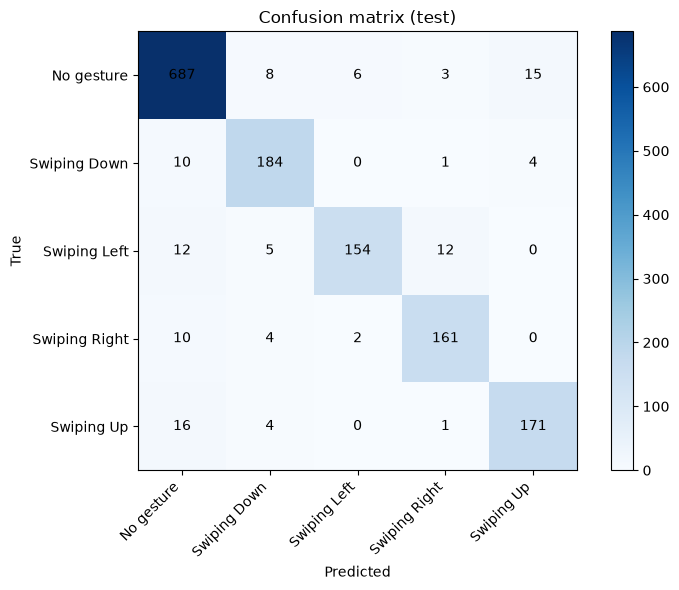

In [ ]:
test_loss, test_acc = run_epoch(test_loader, model, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        logits = model(sequences)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()